# AMO Case — Продуктовий аналітик

**Контекст:** пів року тому підписку підняли з 6.99 до 9.99/тиж (тест показав, що конверсії не впали). CEO сумнівається: ціна зросла на 42%, а в реальному Revenue таких цифр немає. Наше завдання — розібратися.

## Дорожня карта

| Блок | Що робимо |
|---|---|
| **0** | Завантаження + чистка (дублі, типи, sanity-check) |
| **1** | A/B: конверсії click → purchase → otp_purchase по сегментах + стат. значущість |
| **2** | LTV на 1.5 міс для 6.99 vs 9.99 (з урахуванням refund / chargeback / OTP) |
| **3** | Чи справді ARPU зріс на +42%? Гроші за період 26.01–16.03 |
| **4** | ROAS по сегментах (канал / регіон / цінова група) |
| **Підсумок** | Висновок + рекомендація щодо ціни |

In [1]:
# --- 1. Імпорти ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# --- 2. Налаштування відображення ---
pd.set_option('display.max_columns', None)

# --- 3. Завантаження 6 CSV з папки data/ ---
df_order_data = pd.read_csv('data/order_data.csv')
df_otp_data = pd.read_csv('data/otp_data.csv')
df_refunds_data = pd.read_csv('data/refunds_cb_data.csv')
df_test_data = pd.read_csv('data/test_data.csv')
df_user_data = pd.read_csv('data/user_data.csv')
df_marketing_spend_data = pd.read_csv('data/marketing_spend_data.csv')


### Швидка перевірка, що все завантажилось

Виводимо розмір кожної таблиці (`.shape`) і дивимось на перші рядки (`.head()`).

In [2]:
# Перевірка завантаження
print(f"Маркетингові витрати: {df_marketing_spend_data.shape[0]} рядків, {df_marketing_spend_data.shape[1]} стовпців")
print(f"Замовлення (order): {df_order_data.shape[0]} рядків, {df_order_data.shape[1]} стовпців")
print(f"OTP-апсели: {df_otp_data.shape[0]} рядків, {df_otp_data.shape[1]} стовпців")
print(f"Рефанди/чарджбеки: {df_refunds_data.shape[0]} рядків, {df_refunds_data.shape[1]} стовпців")
print(f"A/B-тест: {df_test_data.shape[0]} рядків, {df_test_data.shape[1]} стовпців")
print(f"Користувачі: {df_user_data.shape[0]} рядків, {df_user_data.shape[1]} стовпців")


Маркетингові витрати: 609 рядків, 7 стовпців
Замовлення (order): 342616 рядків, 6 стовпців
OTP-апсели: 44110 рядків, 3 стовпців
Рефанди/чарджбеки: 215088 рядків, 5 стовпців
A/B-тест: 127598 рядків, 9 стовпців
Користувачі: 215088 рядків, 5 стовпців


In [3]:
display(df_marketing_spend_data.head())
display(df_order_data.head())
display(df_otp_data.head())
display(df_refunds_data.head())
display(df_test_data.head())
display(df_user_data.head())


,date,channel,country_group,group,clicks,cpc,spend
0,2025-01-05,Facebook,EU,control,2,0.6992,1.40
1,2025-01-05,Facebook,EU,test,1,0.7836,0.78
2,2025-01-05,Facebook,Tier1,test,1,0.7426,0.74
3,2025-01-05,Facebook,USA,control,4,0.7768,3.11
4,2025-01-05,Facebook,USA,test,2,0.8074,1.61


,user_uuid,date_started,Product Name,order_date,Trial Period Days,Rebill Period Days
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,2025-02-19,weekly 6.99,2025-02-26,7,7
1,9a15cd24-d957-49c6-9e83-1f5cb8897280,2025-02-19,weekly 6.99,2025-03-05,7,7
2,f5fa6241-e57f-45d9-9013-ff0956fb5d91,2025-03-14,weekly 6.99,2025-03-21,7,7
3,6face9f9-76dd-44fb-bfc8-d5676071b311,2025-02-26,weekly 6.99,2025-03-05,7,7
4,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,2025-02-12,weekly 9.99,2025-02-19,7,7


,user_uuid,Product Name,revenue
0,dfd3ab19-6189-4404-82e4-f1f0c0a3922c,one time payment,15
1,0b62b33e-b439-445e-9758-6f604c865609,one time payment,15
2,7802c61c-5a0d-4942-aca6-1f3908474add,one time payment,15
3,3d4ceb0e-b061-48d9-a717-4fa32e737053,one time payment,15
4,4bb69bca-52c6-4d99-be62-328cdd4430d4,one time payment,15


,user_uuid,Product Name,refund,chargeback,price
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,weekly 6.99,0,0,6.99
1,f5fa6241-e57f-45d9-9013-ff0956fb5d91,weekly 6.99,0,0,6.99
2,6face9f9-76dd-44fb-bfc8-d5676071b311,weekly 6.99,0,0,6.99
3,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,weekly 9.99,0,0,9.99
4,b6c932a7-174e-4ff3-8e95-17342b4e54c9,weekly 6.99,0,0,6.99


,user_id,event_date,event_name,group,country_group,platform,payment_method,product_name,channel
0,bd02dd19-1250-4902-877a-818617262946,2025-01-18,click,control,Tier1,Android,card,Weekly 6.99,Facebook
1,4c78ff37-7f18-412f-aff3-b7109100b922,2025-01-19,click,control,EU,Android,card,Weekly 6.99,Organic
2,9e2ced6a-dd70-4836-ba96-ee71c4165980,2025-01-13,click,test,USA,IOS,paypal,Weekly 9.99,Google
3,bab3f720-3ada-47a8-b9c3-e9310bd4ef7c,2025-01-13,click,test,EU,Android,paypal,Weekly 9.99,Google
4,eca01a89-0126-4d33-ac46-a0481dcd7220,2025-01-24,purchase,test,USA,IOS,card,Weekly 9.99,Facebook


,user_uuid,region,platform,payment_type,age_segment
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,USA,Android,card,31-45
1,f5fa6241-e57f-45d9-9013-ff0956fb5d91,USA,IOS,card,31-45
2,6face9f9-76dd-44fb-bfc8-d5676071b311,USA,Android,card,31-45
3,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,USA,IOS,card,18-30
4,b6c932a7-174e-4ff3-8e95-17342b4e54c9,USA,Android,card,31-45


## Блок 0.1: якість даних

In [4]:
dfs = {'test': df_test_data, 'order': df_order_data, 'otp': df_otp_data,
       'refunds': df_refunds_data, 'user': df_user_data, 'mkt': df_marketing_spend_data}

for name, df in dfs.items():
    print(name, '→ повних дублів:', df.duplicated().sum())

df_test_data[df_test_data.duplicated(keep=False)]['group'].value_counts()

df_test_clean = df_test_data.drop_duplicates()
display(df_test_data.shape[0])
display(df_test_clean.shape[0])
display(pd.crosstab(df_test_clean['group'], df_test_clean['product_name']))

df_test_only = df_test_clean[df_test_clean['group'] == 'test']
df_control_only = df_test_clean[df_test_clean['group'] == 'control']
display(pd.crosstab(df_test_only['country_group'], df_test_only['product_name']))
display(pd.crosstab(df_control_only['country_group'], df_control_only['product_name']))


test → повних дублів: 1131
order → повних дублів: 0
otp → повних дублів: 0


refunds → повних дублів: 0
user → повних дублів: 0
mkt → повних дублів: 0


127598

126467

product_name,Weekly 6.99,Weekly 9.99
group,,
control,65439,0
test,6209,54819


product_name,Weekly 6.99,Weekly 9.99
country_group,,
EU,0,30191
Tier1,6209,0
USA,0,24628


product_name,Weekly 6.99
country_group,
EU,32431
Tier1,6601
USA,26407


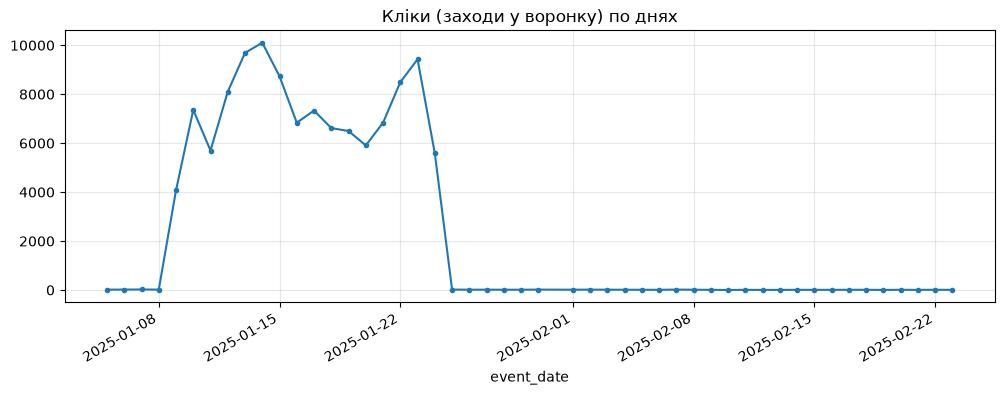

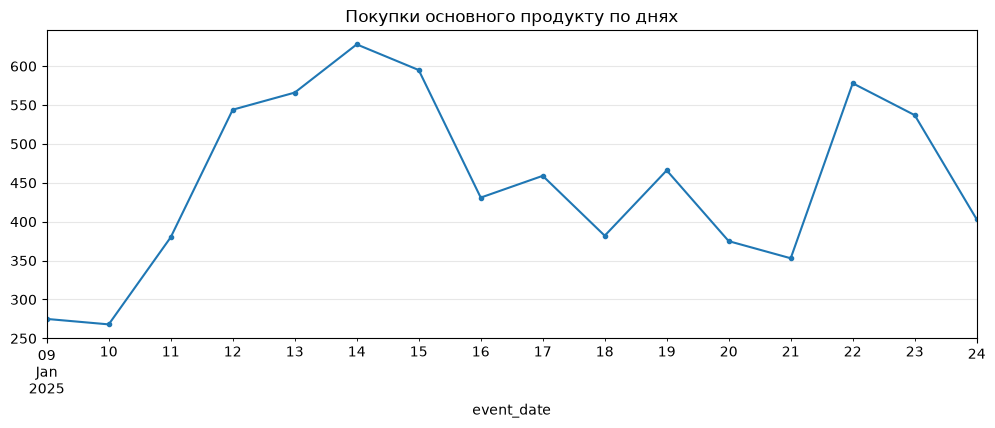

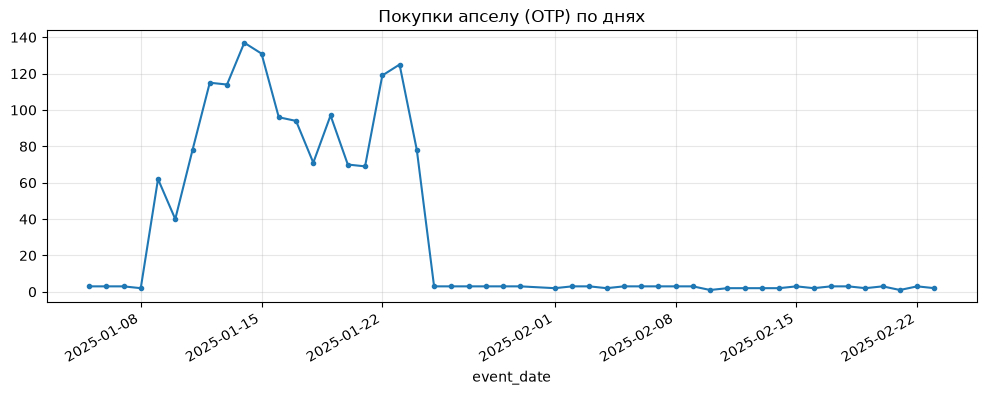

,min,max
event_name,,
click,2025-01-05,2025-02-23
otp_purchase,2025-01-05,2025-02-23
purchase,2025-01-09,2025-01-24


In [5]:
period_start = pd.Timestamp('2025-01-11')
period_end = pd.Timestamp('2025-01-24')

df_test_clean['event_date'] = pd.to_datetime(df_test_clean['event_date'])

events = {
    'click':        'Кліки (заходи у воронку)',
    'purchase':     'Покупки основного продукту',
    'otp_purchase': 'Покупки апселу (OTP)',
}

for event, description in events.items():
    daily = (df_test_clean[df_test_clean['event_name'] == event]
             .groupby('event_date')['user_id'].nunique())
    daily.plot(figsize=(12, 4), marker='.', title=f'{description} по днях')
    plt.grid(True, alpha=0.3)
    plt.show()

df_test_clean.groupby('event_name')['event_date'].agg(['min', 'max'])

**Висновки Блоку 0:**
1) Валідне вікно тесту: **з 2025-01-11 по 2025-01-24** — дні, коли ОБИДВІ групи повноцінно трекались.
2) У тесті були повні дублі рядків (1131 шт., усі в control/click) → почищено через `drop_duplicates()`.
3) **Контамінація Tier1:** у тест-групі ВЕСЬ Tier1 має product_name weekly 6.99 (6209 рядків) → ціна 9.99 у Tier1 не була доставлена, фактично це A/A.
4) **Два «однобокі» дні на старті (баг сплітовалки/трекінгу):**
   — **09.01: працював лише control** (4 073 клікери, 275 покупок; test відсутній повністю);
   — **10.01: кліки в обох групах (3 717 vs 3 642), але покупки й OTP лише в test** (control: 0 покупок, 0 OTP; test: 268 покупок, 40 OTP). Оскільки 100% покупок відбуваються в день кліка, це не «затримка конверсії» — день несиметричний і виключений.
   Обидва дні прибрано з вікна; хвости до 09.01 і після 24.01 — незначні обсяги без покупок.

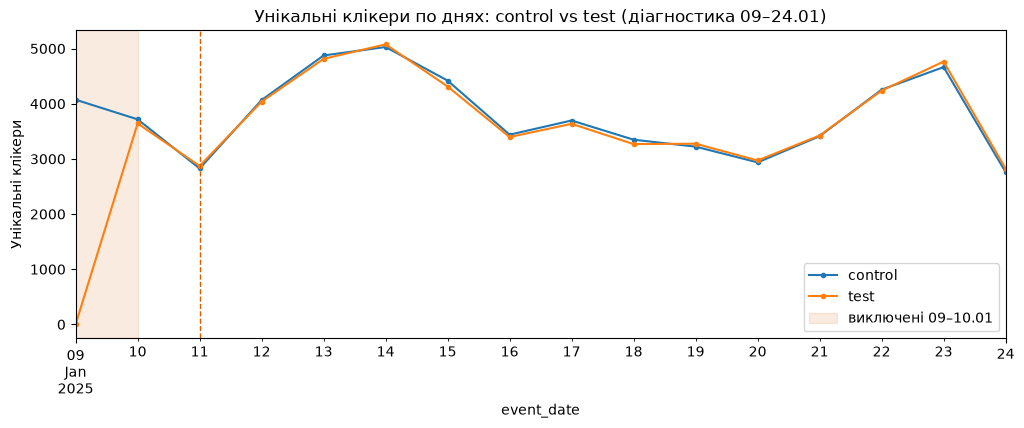

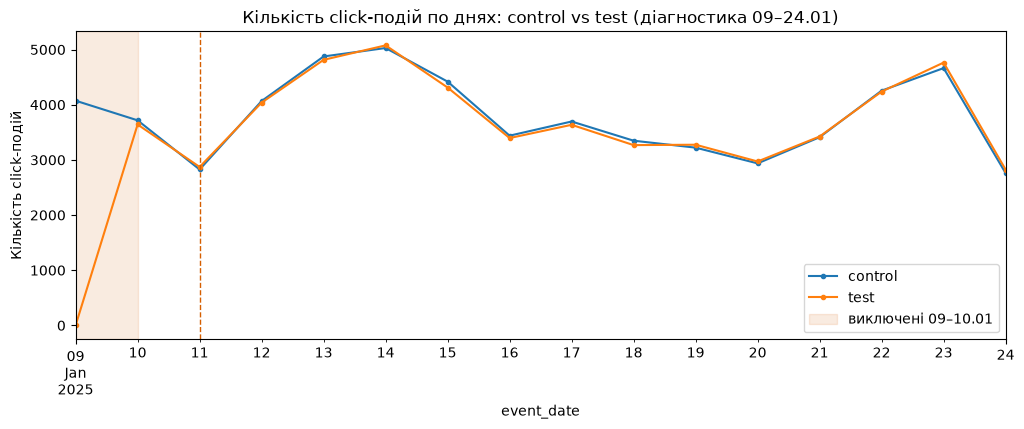

In [6]:
df_period = df_test_clean[
    (df_test_clean['event_date'] >= period_start) &
    (df_test_clean['event_date'] < period_end + pd.Timedelta(days=1))
].copy()

# Діагностичне вікно включає 09–10.01, щоб було видно, чому їх виключено.
audit_start = period_start - pd.Timedelta(days=2)
df_audit = df_test_clean[
    (df_test_clean['event_date'] >= audit_start) &
    (df_test_clean['event_date'] < period_end + pd.Timedelta(days=1))
].copy()
clicks_audit = df_audit[df_audit['event_name'] == 'click'].copy()

daily_clickers = (clicks_audit
    .groupby(['event_date', 'group'])['user_id'].nunique()
    .unstack(fill_value=0))

ax = daily_clickers.plot(
    figsize=(12, 4), marker='.',
    title='Унікальні клікери по днях: control vs test (діагностика 09–24.01)')
ax.axvspan(audit_start - pd.Timedelta(hours=12),
           period_start - pd.Timedelta(hours=12),
           color='#D55E00', alpha=0.12, label='виключені 09–10.01')
ax.axvline(period_start, color='#D55E00', linestyle='--', linewidth=1)
ax.set_ylabel('Унікальні клікери')
ax.legend()
plt.show()

# Другий погляд на ті самі дні: кількість усіх click-подій після видалення дублів.
daily_click_events = (clicks_audit
    .groupby(['event_date', 'group'])
    .size()
    .unstack(fill_value=0))

ax = daily_click_events.plot(
    figsize=(12, 4), marker='.',
    title='Кількість click-подій по днях: control vs test (діагностика 09–24.01)')
ax.axvspan(audit_start - pd.Timedelta(hours=12),
           period_start - pd.Timedelta(hours=12),
           color='#D55E00', alpha=0.12, label='виключені 09–10.01')
ax.axvline(period_start, color='#D55E00', linestyle='--', linewidth=1)
ax.set_ylabel('Кількість click-подій')
ax.legend()
plt.show()

In [7]:
# --- Ізоляція хвоста (все, що поза вікном 11–24 січня) ---
d = df_test_clean['event_date']
tail = df_test_clean[(d < period_start) | (d > period_end)].copy()

# Q1: обсяг і типи подій (чи є purchase?)
print("=== Q1: обсяг і типи подій у хвості ===")
print("Всього рядків:", tail.shape[0])
print(tail['event_name'].value_counts())

# Q2: коли — до 11-го і/або після 24-го
print("\n=== Q2: коли ===")
before = tail[tail['event_date'] < period_start]
after  = tail[tail['event_date'] > period_end]
print(f"До 11.01:    {before.shape[0]} рядків  ({before['event_date'].min()} -> {before['event_date'].max()})")
print(f"Після 24.01: {after.shape[0]} рядків  ({after['event_date'].min()} -> {after['event_date'].max()})")

# Q3: баланс по групах і регіонах
print("\n=== Q3: баланс group x country ===")
print(tail.groupby(['group', 'country_group']).size())

# Q4: otp у хвості — це ті самі «сироти» (otp без purchase)?
print("\n=== Q4: otp-сироти ===")
tail_otp_users = set(tail[tail['event_name'] == 'otp_purchase']['user_id'])
purchase_users = set(df_test_clean[df_test_clean['event_name'] == 'purchase']['user_id'])
orphans = tail_otp_users - purchase_users
print("otp-юзерів у хвості:", len(tail_otp_users))
print("з них НІКОЛИ не купували основний продукт:", len(orphans))

=== Q1: обсяг і типи подій у хвості ===
Всього рядків: 12521
event_name
click           11791
purchase          543
otp_purchase      187
Name: count, dtype: int64

=== Q2: коли ===
До 11.01:    12159 рядків  (2025-01-05 00:00:00 -> 2025-01-10 00:00:00)
Після 24.01: 362 рядків  (2025-01-25 00:00:00 -> 2025-02-23 00:00:00)

=== Q3: баланс group x country ===
group    country_group
control  EU               4111
         Tier1             839
         USA              3333
test     EU               2067
         Tier1             441
         USA              1730
dtype: int64

=== Q4: otp-сироти ===
otp-юзерів у хвості: 187
з них НІКОЛИ не купували основний продукт: 85


## Блок 1: Рахуємо CR (вікно 11–24.01)

In [8]:
df_period = df_test_clean[
    (df_test_clean['event_date'] >= period_start) &
    (df_test_clean['event_date'] < period_end + pd.Timedelta(days=1))
].copy()

regions = ['EU', 'USA', 'Tier1']
groups = ['control', 'test']

for reg in regions:
    for grp in groups:
        subset = df_period[
            (df_period['country_group'] == reg) &
            (df_period['group'] == grp)
        ]
        clickers = df_period[(df_period['event_name'] == 'click') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        buyers   = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        tier1_test = df_period[(df_period['country_group'] == 'Tier1') & (df_period['group'] == 'test')]
        test_arm   = df_period[df_period['group'] == 'test']
        share = tier1_test['user_id'].nunique() / test_arm['user_id'].nunique()
        print(
            "конверсія з кліка в покупку:"
            " "
            f"{reg} {grp}: "
            f"{subset.shape[0]} рядків, "
            f"CR = {round(100*buyers/clickers, 2)}%"
        )

for reg in regions:
    for grp in groups:
        subset = df_period[
            (df_period['country_group'] == reg) &
            (df_period['group'] == grp)
        ]
        purchases = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        otp_buyers = df_period[(df_period['event_name'] == 'otp_purchase') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        print(
            "конверсія з покупки в апсел:"
            " "
            f"{reg} {grp}: "
            f"{subset.shape[0]} рядків, "
            f"attach = {round(100*otp_buyers/purchases, 2)}%"
        )

print(f"Частка Tier1 у тест-армі (контамінація) = {round(100*share, 2)}%")


конверсія з кліка в покупку: EU control: 28320 рядків, CR = 5.59%
конверсія з кліка в покупку: EU test: 28124 рядків, CR = 5.4%


конверсія з кліка в покупку: USA control: 23074 рядків, CR = 7.48%
конверсія з кліка в покупку: USA test: 22898 рядків, CR = 6.97%


конверсія з кліка в покупку: Tier1 control: 5762 рядків, CR = 6.8%
конверсія з кліка в покупку: Tier1 test: 5768 рядків, CR = 6.94%
конверсія з покупки в апсел: EU control: 28320 рядків, attach = 24.59%
конверсія з покупки в апсел: EU test: 28124 рядків, attach = 16.79%
конверсія з покупки в апсел: USA control: 23074 рядків, attach = 19.56%
конверсія з покупки в апсел: USA test: 22898 рядків, attach = 17.55%


конверсія з покупки в апсел: Tier1 control: 5762 рядків, attach = 30.56%
конверсія з покупки в апсел: Tier1 test: 5768 рядків, attach = 30.25%
Частка Tier1 у тест-армі (контамінація) = 10.0%


**Tier1 = фактично A/A-тест.** Ціна в обох групах Tier1 однакова (6.99), тож він перевіряє справність механіки спліта. Різниця CR 6.92 − 6.36 = **0.56 п.п.** — це масштаб природного шуму на цих обсягах.

**Контамінація:** кожен десятий юзер «тест»-арму (Tier1, 10%) насправді бачив 6.99, а не 9.99. Висновки:
- аналізувати тест можна лише в розбивці по регіонах — злитий control-vs-test був би забруднений 10% старої ціни;
- це обмеження стосується лише A/B-тесту. У rollout-даних регіон Other бачить обидві ціни; недоставкою Tier1 не можна пояснювати різницю платних когорт або слабкий Revenue.

# Блок 1. A/B-тест: статистична значущість (z-тести)

In [9]:
# z-тести на df_period (вікно задане ОДИН раз вище — тут НЕ перевизначаємо)

regions = ['EU', 'USA', 'Tier1']

# --- CR: click -> purchase ---
print('CR (click -> purchase):')
for reg in regions:
    clk_c = df_period[(df_period['event_name'] == 'click') & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
    buy_c = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
    clk_t = df_period[(df_period['event_name'] == 'click') & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()
    buy_t = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()

    z, p = proportions_ztest(count=[buy_c, buy_t], nobs=[clk_c, clk_t])
    print(f"{reg}: z = {z:.3f}, p = {p:.4f}")

# --- Attach: purchase -> otp_purchase ---
print('\nAttach (purchase -> otp_purchase):')
for reg in regions:
    purch_c = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
    opurch_c = df_period[(df_period['event_name'] == 'otp_purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
    purch_t = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()
    opurch_t = df_period[(df_period['event_name'] == 'otp_purchase') & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()

    z, p = proportions_ztest(count=[opurch_c, opurch_t], nobs=[purch_c, purch_t])
    print(f"{reg}: z = {z:.3f}, p = {p:.4f}")


# --- 95% довірчі інтервали різниці (test − control), у п.п. ---
import numpy as np
print('\n95% CI різниці часток (test − control):')
for label, ev_num, ev_den in [('CR', 'purchase', 'click'), ('attach', 'otp_purchase', 'purchase')]:
    for reg in regions:
        n1 = df_period[(df_period['event_name'] == ev_den) & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
        x1 = df_period[(df_period['event_name'] == ev_num) & (df_period['country_group'] == reg) & (df_period['group'] == 'control')]['user_id'].nunique()
        n2 = df_period[(df_period['event_name'] == ev_den) & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()
        x2 = df_period[(df_period['event_name'] == ev_num) & (df_period['country_group'] == reg) & (df_period['group'] == 'test')]['user_id'].nunique()
        p1, p2 = x1 / n1, x2 / n2
        d = p2 - p1
        se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
        print(f"{label} {reg}: diff = {100*d:+.2f} п.п., CI [{100*(d - 1.96*se):+.2f}; {100*(d + 1.96*se):+.2f}] п.п.")


CR (click -> purchase):
EU: z = 0.951, p = 0.3418


USA: z = 2.024, p = 0.0430
Tier1: z = -0.274, p = 0.7839

Attach (purchase -> otp_purchase):
EU: z = 5.185, p = 0.0000
USA: z = 1.429, p = 0.1530
Tier1: z = 0.091, p = 0.9275

95% CI різниці часток (test − control):
CR EU: diff = -0.19 п.п., CI [-0.58; +0.20] п.п.


CR USA: diff = -0.51 п.п., CI [-1.00; -0.02] п.п.


CR Tier1: diff = +0.13 п.п., CI [-0.83; +1.10] п.п.
attach EU: diff = -7.80 п.п., CI [-10.73; -4.87] п.п.
attach USA: diff = -2.01 п.п., CI [-4.76; +0.74] п.п.


attach Tier1: diff = -0.31 п.п., CI [-7.00; +6.38] п.п.


**Висновки z-тестів (вікно 11–24.01):**
- **EU: жодного сигналу зміни CR** (5.59% → 5.40%, p=0.34; 95% CI різниці [−0.58; +0.20] п.п.).
- **USA: слабкий сигнал НЕВЕЛИКОГО падіння CR** — 7.48% → 6.97% (−0.51 п.п.), p=0.043, CI [−1.00; −0.02] п.п.
  Це на межі значущості: ми робимо 6 порівнянь без заздалегідь заданої поправки (з поправкою
  Бонферроні — не значуще), тож трактуємо обережно: «падіння, якщо і є, не перевищує ~1 п.п.».
- **Апсел: значуще падіння attach у EU** — 24.59% → 16.79% (−7.8 п.п., CI [−10.7; −4.9], p<0.0001).
  У USA той самий нахил (−2.0 п.п., CI [−4.8; +0.7]), не значуще.
- **Tier1 (A/A): чисто** (CR p=0.78, attach p=0.93) — хибних спрацювань немає.

**Помилка компанії:** «конверсія не впала» було приблизно правдою (зміни ≤1 п.п.), але вони
не перевірили апсел, який у EU просів на третину — і саме там зникає суттєва частина грошей.

## Блок 1.1: апсел — контрфактуал і цінність оформлення (checkout value)

**Що рахуємо.** За уточненням Максима тріал безкоштовний, і перший платіж за підписку
відбувається на 7-й день — а платіжних даних для юзерів тесту не існує (популяції test_data
і order_data не перетинаються). Тому нижче рахуємо **«цінність оформлення» (checkout value)
= ціна підписки + attach × $15** — потенційну цінність першого платіжного циклу за умови
успішного першого списання. Модель застосовується до обох груп симетрично, тож відносні
висновки (механіка, канібалізація) від цього припущення не залежать. Фактичні гроші —
у Блоках 2–3 на даних розкатки.

**Терміни декомпозиції (використовуються тут і в Блоці 2):**
- **«Механіка» (структурний ефект):** ціну підняли лише підписці (+42.9%), а апсел OTP як коштував \$15, так і коштує → частина виручки не росте взагалі, тому середній ріст математично МЕНШИЙ за +42.9% — навіть якби поведінка юзерів не змінилась ні на йоту. Розмір ефекту = 42.9% × частка OTP у виручці.
- **«Канібалізація» (поведінковий ефект):** через дорожчу підписку юзери РІДШЕ докуповують OTP (attach rate падає) — це вже реальна зміна поведінки, а не арифметика.

In [10]:
regions = ['EU', 'USA', 'Tier1']
groups  = ['control', 'test']
price_map = {'Weekly 6.99': 6.99, 'Weekly 9.99': 9.99}
OTP_PRICE = 15

def uniq(reg, grp, ev):
    return df_period[(df_period['event_name'] == ev) &
                     (df_period['country_group'] == reg) &
                     (df_period['group'] == grp)]['user_id'].nunique()

def price_of(reg, grp):
    prods = df_period[(df_period['country_group'] == reg) &
                      (df_period['group'] == grp)]['product_name'].unique()
    assert len(prods) == 1, f'{reg}/{grp}: неоднорідний продукт -> {prods}'
    return price_map[prods[0]]

# --- 1. Довга таблиця: метрики по регіону × групі ---
rows = []
for reg in regions:
    for grp in groups:
        clickers = uniq(reg, grp, 'click')
        buyers   = uniq(reg, grp, 'purchase')
        otp      = uniq(reg, grp, 'otp_purchase')
        price    = price_of(reg, grp)          # ← ціна З ДАНИХ, не з групи
        rev_sub  = buyers * price
        rev_otp  = otp * OTP_PRICE
        rev_all  = rev_sub + rev_otp
        rows.append({
            'регіон': reg,
            'група': grp,
            'клікери': clickers,
            'покупці': buyers,
            'апсели': otp,
            'CR_%': round(100 * buyers / clickers, 2),
            'attach_%': round(100 * otp / buyers, 2),
            'ціна': price,
            'виручка_підписка': round(rev_sub, 2),
            'виручка_апсел': round(rev_otp, 2),
            'виручка_разом': round(rev_all, 2),
            'цінність_оформлення': round(rev_all / buyers, 2),
        })

result = pd.DataFrame(rows)          # ← СТВОРЮЄМО до pivot
display(result)

# --- 1.5. Півотимо кожну складову виручки: control vs test + різниця в $ і % ---
rev_sub_p = result.pivot(index='регіон', columns='група', values='виручка_підписка')
rev_sub_p['різниця_$'] = round(rev_sub_p['test'] - rev_sub_p['control'], 2)
rev_sub_p['різниця_%'] = round(100 * (rev_sub_p['test'] / rev_sub_p['control'] - 1), 1)

rev_otp_p = result.pivot(index='регіон', columns='група', values='виручка_апсел')
rev_otp_p['різниця_$'] = round(rev_otp_p['test'] - rev_otp_p['control'], 2)
rev_otp_p['різниця_%'] = round(100 * (rev_otp_p['test'] / rev_otp_p['control'] - 1), 1)

rev_all_p = result.pivot(index='регіон', columns='група', values='виручка_разом')
rev_all_p['різниця_$'] = round(rev_all_p['test'] - rev_all_p['control'], 2)
rev_all_p['різниця_%'] = round(100 * (rev_all_p['test'] / rev_all_p['control'] - 1), 1)

print('Виручка з підписки: control vs test (УВАГА: тотали армів — лише довідково, арми різного розміру)')
display(rev_sub_p)
print('Виручка з апселу: control vs test')
display(rev_otp_p)
print('Виручка разом: control vs test')
display(rev_all_p)

# --- 2. Розгортаємо потрібні метрики в широкий вигляд ---
p        = result.pivot(index='регіон', columns='група', values='цінність_оформлення')
price_p  = result.pivot(index='регіон', columns='група', values='ціна')
attach_p = result.pivot(index='регіон', columns='група', values='attach_%')

# --- 3. Світ 2 (контрфактуал): ціна від test, attach від control ---
p['світ2'] = round(price_p['test'] + (attach_p['control'] / 100) * OTP_PRICE, 2)

# --- 4. Розкладання розриву ---
p['наївний_%']    = round(100 * (price_p['test'] / price_p['control'] - 1), 1)   # ріст самої лише ціни
p['ріст_світ2_%'] = round(100 * (p['світ2'] / p['control'] - 1), 1)              # якби attach не впав
p['ріст_факт_%']  = round(100 * (p['test'] / p['control'] - 1), 1)               # реальність

p['механіка_пп']      = round(p['наївний_%'] - p['ріст_світ2_%'], 1)    
p['канібалізація_пп'] = round(p['ріст_світ2_%'] - p['ріст_факт_%'], 1)  

display(p)

,регіон,група,клікери,покупці,апсели,CR_%,attach_%,ціна,виручка_підписка,виручка_апсел,виручка_разом,цінність_оформлення
0,EU,control,26476,1480,364,5.59,24.59,6.99,10345.20,5460,15805.20,10.68
1,EU,test,26455,1429,240,5.40,16.79,9.99,14275.71,3600,17875.71,12.51
2,USA,control,21179,1585,310,7.48,19.56,6.99,11079.15,4650,15729.15,9.92
3,USA,test,21163,1476,259,6.97,17.55,9.99,14745.24,3885,18630.24,12.62
4,Tier1,control,5292,360,110,6.80,30.56,6.99,2516.40,1650,4166.40,11.57
5,Tier1,test,5290,367,111,6.94,30.25,6.99,2565.33,1665,4230.33,11.53


Виручка з підписки: control vs test (УВАГА: тотали армів — лише довідково, арми різного розміру)


група,control,test,різниця_$,різниця_%
регіон,,,,
EU,10345.20,14275.71,3930.51,38.0
Tier1,2516.40,2565.33,48.93,1.9
USA,11079.15,14745.24,3666.09,33.1


Виручка з апселу: control vs test


група,control,test,різниця_$,різниця_%
регіон,,,,
EU,5460,3600,-1860,-34.1
Tier1,1650,1665,15,0.9
USA,4650,3885,-765,-16.5


Виручка разом: control vs test


група,control,test,різниця_$,різниця_%
регіон,,,,
EU,15805.20,17875.71,2070.51,13.1
Tier1,4166.40,4230.33,63.93,1.5
USA,15729.15,18630.24,2901.09,18.4


група,control,test,світ2,наївний_%,ріст_світ2_%,ріст_факт_%,механіка_пп,канібалізація_пп
регіон,,,,,,,,
EU,10.68,12.51,13.68,42.9,28.1,17.1,14.8,11.0
Tier1,11.57,11.53,11.57,0.0,0.0,-0.3,0.0,0.3
USA,9.92,12.62,12.92,42.9,30.2,27.2,12.7,3.0


**Висновок Завдання 1.**
1. Помітного падіння конверсії в покупку немає: EU — жодного сигналу (p=0.34, CI [−0.58; +0.20] п.п.);
   USA — слабкий сигнал малого падіння (−0.5 п.п., p=0.043, на межі значущості; з поправкою на
   множинні порівняння — не значуще). У будь-якому разі зміни CR ≤ 1 п.п.
2. Але апсел компанія не перевіряла: attach у EU впав 24.6% → 16.8% (−32% відносно,
   CI [−10.7; −4.9] п.п., p<0.0001) — дорожча підписка канібалізує OTP.
3. Цінність оформлення (checkout value, модель першого циклу): EU +17.1% замість наївних
   +42.9% (механіка 14.8 п.п. + канібалізація 11.0 п.п.); USA +27.2%.
4. Tier1 не отримав ціну 9.99 (контамінація) → виключений з цінових порівнянь, використаний
   як A/A sanity-check. Знайдено ДВА «однобокі» дні збору даних (09.01 — лише control,
   10.01 — покупки лише в test) → вікно 11–24.01.

# Блок 2: LTV на 1.5 місяця (розкатка 9.99 на 50% трафіку)

Дані розкатки: `order_data`, `otp_data`, `refunds_cb_data`, `user_data`. Ключ — `user_uuid`. Популяція НЕ перетинається з учасниками A/B-тесту (перевірено: overlap = 0).

**Умови та додаткова інформація від Макса:**
- оплати відбуваються **лише в дати `order_date`**; `date_started` — це просто старт юзера в додатку (безкоштовний тріал), за ним формуємо когорти;
- **перший фактичний платіж = перший `order_date`** (day 7); другий платіж = перший ребіл;
- база LTV = **100% юзерів `order_data`** (усі вони мають перший платіж);
- горизонт «1.5 місяця» автори трактують як **49 днів (7 списань)** — беремо його ж.

In [11]:
# --- Розвідка order_data ---
df_order_data.info()
df_order_data[['user_uuid', 'date_started', 'Product Name', 'order_date', 'Trial Period Days', 'Rebill Period Days']].value_counts()
for col in df_order_data.columns:
    print(f'\n--- {col} ---')
    print(df_order_data[col].value_counts())

# Скільки рядків (списань) на юзера
subscriptions_per_user = (
    df_order_data
    .groupby('user_uuid')
    .size()
)
subscriptions_per_user.value_counts().sort_index()

# Перетворюємо дати з тексту на справжні дати
df_order_data['date_started'] = pd.to_datetime(df_order_data['date_started'])
df_order_data['order_date'] = pd.to_datetime(df_order_data['order_date'])

# Скільки днів минуло від старту до кожного списання
df_order_data['diff_days'] = (df_order_data['order_date'] - df_order_data['date_started']).dt.days

retention_table = (
    df_order_data
    .groupby(['Product Name', 'diff_days'])['user_uuid']
    .nunique()
    .rename('юзерів')
    .reset_index()
)

retention_table['retention_%'] = (
    retention_table['юзерів']
    / retention_table.groupby('Product Name')['юзерів'].transform('first')
    * 100
).round(2)

print('УВАГА: це ДІАГНОСТИЧНА таблиця без поправки на цензурування —')
print('пізні дні занижені, бо не всі юзери встигли їх прожити.')
print('Коректний retention (eligible-знаменник) — у Блоці 2 нижче.')
retention_table.set_index(['Product Name', 'diff_days'])


<class 'pandas.DataFrame'>
RangeIndex: 342616 entries, 0 to 342615
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   user_uuid           342616 non-null  str  
 1   date_started        342616 non-null  str  
 2   Product Name        342616 non-null  str  
 3   order_date          342616 non-null  str  
 4   Trial Period Days   342616 non-null  int64
 5   Rebill Period Days  342616 non-null  int64
dtypes: int64(2), str(4)
memory usage: 37.6 MB

--- user_uuid ---


user_uuid
d7d9bde5-c2d2-495a-b7df-bc9ae599ae38    7
121191b3-d617-4cd7-bde0-c6cca0e85c3e    7
3573a6ff-4c34-4b77-8160-b3f05b107d04    7
425f958b-465b-42de-b1bb-55f31226f5df    7
484842d5-ea5e-4065-b83a-f50672468ce0    7
                                       ..
7d7e16bc-d607-4fc7-b023-f13fd7b65e58    1
82694c4b-c396-42a3-aac3-64545496387c    1
4ce01707-b8e0-40a7-8fcd-af5cf8e140c7    1
377603f9-9672-4c3d-9920-e6338ae4f694    1
119596be-9f8b-4c19-be29-d12dd9e17062    1
Name: count, Length: 215088, dtype: int64

--- date_started ---
date_started
2025-01-25    10577
2025-02-03    10365
2025-01-30    10176
2025-02-11    10164
2025-02-02    10146
2025-01-27     9958
2025-02-05     9200
2025-03-06     9107
2025-02-01     8702
2025-01-26     8702
2025-02-26     8645
2025-02-25     8544
2025-02-08     8312
2025-02-24     8256
2025-02-04     8009
2025-02-12     7903
2025-02-22     7899
2025-01-28     7826
2025-02-28     7695
2025-02-09     7572
2025-02-10     7186
2025-02-13     7058
2025-02-19 

УВАГА: це ДІАГНОСТИЧНА таблиця без поправки на цензурування —
пізні дні занижені, бо не всі юзери встигли їх прожити.
Коректний retention (eligible-знаменник) — у Блоці 2 нижче.


юзерів  retention_%
Product Name diff_days                     
weekly 6.99  7          112382       100.00
             14          47640        42.39
             21          19008        16.91
             28           8651         7.70
             35           3245         2.89
             42           1707         1.52
             49            704         0.63
weekly 9.99  7          102706       100.00
             14          27629        26.90
             21          10883        10.60
             28           4890         4.76
             35           1825         1.78
             42            964         0.94
             49            382         0.37

In [12]:
# Рядок order_data = фактичне СПИСАННЯ
# Перший рядок юзера (day 7) = перший платіж (конверсія з безкоштовного тріалу),
# наступні рядки — ребіли. Тож кількість платежів юзера = кількість його рядків.

products = ['weekly 6.99', 'weekly 9.99']

for product in products:
    df_product = df_order_data[
        df_order_data['Product Name'] == product
    ]

    # Платежі (списання) кожного користувача по цьому продукту
    payments_per_user = df_product.groupby('user_uuid').size()

    # Розподіл: скільки юзерів мають 1, 2, 3 ... списань
    payments_distribution = (
        payments_per_user
        .value_counts()
        .sort_index()
        .rename_axis('кількість_списань')
        .rename('юзерів')
        .to_frame()
    )

    print(f'\n{product}')
    display(payments_distribution)


weekly 6.99


,юзерів
кількість_списань,
1,64742
2,28632
3,10357
4,5406
5,1538
6,1003
7,704



weekly 9.99


,юзерів
кількість_списань,
1,75077
2,16746
3,5993
4,3065
5,861
6,582
7,382


In [13]:
HORIZON   = 49       # 1.5 місяця = 49 днів (7 списань) — трактовка авторів кейсу
OTP_PRICE = 15
CB_FINE   = 30
price_map = {'weekly 6.99': 6.99, 'weekly 9.99': 9.99}

# --- Підготовка ---
o = df_order_data.copy()
o['date_started'] = pd.to_datetime(o['date_started'])
o['order_date']   = pd.to_datetime(o['order_date'])
o['diff_days']    = (o['order_date'] - o['date_started']).dt.days
END = o['order_date'].max()          # кінець спостереження

# --- Профіль юзера: когорта, старт, скільки днів встигли спостерігати ---
users = (o.groupby('user_uuid')
           .agg(product=('Product Name', 'first'), date_started=('date_started', 'first'))
           .reset_index())
users['price']    = users['product'].map(price_map)
users['obs_days'] = (END - users['date_started']).dt.days

# платежі (списання) всередині горизонту: 1-ше списання (d7) + ребіли до d49
pays = o[o['diff_days'] <= HORIZON].groupby('user_uuid').size().rename('pays')
users = users.merge(pays, on='user_uuid', how='left')
users['pays'] = users['pays'].fillna(0).astype(int)

# --- RETENTION з поправкою на цензурування ---
rows = []
for d in [7, 14, 21, 28, 35, 42, 49]:
    for prod in ['weekly 6.99', 'weekly 9.99']:
        elig  = (users['product'].eq(prod) & users['obs_days'].ge(d)).sum()   # МОГЛИ дожити
        alive = o[(o['Product Name'] == prod) & (o['diff_days'] == d)]['user_uuid'].nunique()
        rows.append({'день': d, 'product': prod,
                     'retention_%': round(100 * alive / elig, 2) if elig else None})
ret = pd.DataFrame(rows).pivot(index='день', columns='product', values='retention_%')
display(ret)

# --- LTV на 49 днів (тільки повністю спостережені юзери, obs >= 49) ---
full = users[users['obs_days'] >= HORIZON].copy()
full['rev_sub'] = full['pays'] * full['price']   # платежі = РЯДКИ order_data (без жодних +1)

otp_users = set(df_otp_data['user_uuid'])
full['rev_otp'] = full['user_uuid'].isin(otp_users).astype(int) * OTP_PRICE

full = full.merge(df_refunds_data[['user_uuid', 'refund', 'chargeback']], on='user_uuid', how='left')
full[['refund', 'chargeback']] = full[['refund', 'chargeback']].fillna(0)
full['loss_ref'] = full['refund']     * full['price']              # рефанд = повернення одного ордера
full['loss_cb']  = full['chargeback'] * (full['price'] + CB_FINE)  # чарджбек = ордер + $30 штрафу

full['LTV'] = full['rev_sub'] + full['rev_otp'] - full['loss_ref'] - full['loss_cb']

ltv = full.groupby('product').agg(
    юзерів=('user_uuid', 'size'),
    списань_сер=('pays', 'mean'),
    підписка=('rev_sub', 'mean'),
    otp=('rev_otp', 'mean'),
    рефанди=('loss_ref', 'mean'),
    чарджбеки=('loss_cb', 'mean'),
    LTV=('LTV', 'mean')).round(3)
display(ltv)
print(f"Ріст LTV: {100 * (ltv.loc['weekly 9.99','LTV'] / ltv.loc['weekly 6.99','LTV'] - 1):.1f}%   (наївне очікування +42.9%)")

# --- По сегментах (join з user_data по user_uuid) ---
full = full.merge(df_user_data[['user_uuid', 'region', 'platform', 'payment_type', 'age_segment']],
                  on='user_uuid', how='left')
for seg_col in ['region', 'platform', 'payment_type', 'age_segment']:
    t = full.pivot_table(index=seg_col, columns='product', values='LTV', aggfunc='mean').round(2)
    t['ріст_%'] = (100 * (t['weekly 9.99'] / t['weekly 6.99'] - 1)).round(1)
    print(f'\n=== LTV по {seg_col} ===')
    display(t)

# --- Опис зрілої когорти (complete-cohort дизайн) ---
print(f"\nЗріла когорта LTV49: старти {full['date_started'].min().date()} – {full['date_started'].max().date()}, "
      f"n = {len(full):,} ({100*len(full)/len(users):.1f}% усіх юзерів order_data).")
print('Це не «втрата даних», а вимога методу: LTV49 можна виміряти лише в тих, хто прожив усі 49 днів.')

# --- Welch 95% CI різниці LTV (9.99 − 6.99) ---
print('\nWelch 95% CI різниці LTV (9.99 − 6.99):')
for scope, mask in [('TOTAL', full['region'].notna())] + [(r, full['region'] == r) for r in ['EU', 'USA', 'Other']]:
    a = full[mask & (full['product'] == 'weekly 9.99')]['LTV']
    b = full[mask & (full['product'] == 'weekly 6.99')]['LTV']
    d = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    print(f"{scope}: diff = {d:+.2f} $, CI [{d - 1.96*se:+.2f}; {d + 1.96*se:+.2f}]  (n = {len(b):,} / {len(a):,})")


product,weekly 6.99,weekly 9.99
день,,
7,100.00,100.00
14,49.14,31.26
21,23.34,14.71
28,13.38,8.35
35,6.33,3.92
42,4.92,3.08
49,4.04,2.42


,юзерів,списань_сер,підписка,otp,рефанди,чарджбеки,LTV
product,,,,,,,
weekly 6.99,17406,1.995,13.947,3.616,0.213,0.062,17.289
weekly 9.99,15770,1.587,15.857,2.674,0.703,0.109,17.718


Ріст LTV: 2.5%   (наївне очікування +42.9%)

=== LTV по region ===


product,weekly 6.99,weekly 9.99,ріст_%
region,,,
EU,17.11,16.71,-2.3
Other,19.09,21.67,13.5
USA,17.40,20.24,16.3



=== LTV по platform ===


...


=== LTV по payment_type ===


product,weekly 6.99,weekly 9.99,ріст_%
payment_type,,,
card,17.50,17.79,1.7
paypal,16.76,17.54,4.7



=== LTV по age_segment ===


product,weekly 6.99,weekly 9.99,ріст_%
age_segment,,,
18-30,15.57,15.93,2.3
31-45,17.24,17.41,1.0
46+,19.02,19.91,4.7



Зріла когорта LTV49: старти 2025-01-25 – 2025-01-31, n = 33,176 (15.4% усіх юзерів order_data).
Це не «втрата даних», а вимога методу: LTV49 можна виміряти лише в тих, хто прожив усі 49 днів.

Welch 95% CI різниці LTV (9.99 − 6.99):
TOTAL: diff = +0.43 $, CI [+0.15; +0.71]  (n = 17,406 / 15,770)
EU: diff = -0.40 $, CI [-0.71; -0.09]  (n = 13,007 / 11,683)
USA: diff = +2.84 $, CI [+2.16; +3.51]  (n = 3,349 / 3,073)
Other: diff = +2.58 $, CI [+1.34; +3.83]  (n = 1,050 / 1,014)


**Читання таблиці LTV (горизонт 49 днів, платежі = рядки order_data; зріла когорта стартів 25–31.01, n = 33 176):**
- **списань_сер** — retention: у 9.99 списань менше (≈1.59 vs ≈2.00) → головний винуватець (−$4.08 на юзера).
- **otp** — та сама канібалізація апселу, що в Завданні 1, тепер у грошах розкатки (−$0.94).
- **рефанди + чарджбеки** — скарга сапорту підтверджується (частка рефандів ≈3% → ≈7%), але в грошах це дрібниця: −$0.40 та −$0.04.
- **Підсумок: у спостережених платників LTV виріс лише на ≈+2.5% замість очікуваних +42.9%** (95% CI різниці: +$0.15…+$0.71 — асоціація позитивна, але мала).
- **Сегменти: серед спостережених платників EU LTV на 9.99 НИЖЧИЙ — −$0.40/юзера, 95% CI [−0.71; −0.09]** — інтервал не містить нуля,
  тобто різниця між ціновими когортами статистично підтримана; це не усуває обмеження причинності rollout-даних. USA (+$2.84, CI [+2.16; +3.51]) та Other
  (+$2.58, CI [+1.34; +3.83]) — впевнено позитивні, але далеко від +42.9%.

*Нагадування термінів: «механіка» = OTP \$15 фіксований і не росте з ціною (структурний ефект); «канібалізація» = юзери рідше беруть OTP через дорожчу підписку (поведінковий ефект). Пояснення — у Блоці 1.1.*

In [14]:
b = ltv.loc['weekly 6.99']; t = ltv.loc['weekly 9.99']
pay_b, pay_t = b['списань_сер'], t['списань_сер']

naive   = b['LTV'] * (9.99 / 6.99)                       # якби ВСЕ зросло на 42.9%
only_pr = pay_b*9.99 + b['otp'] - b['рефанди']*(9.99/6.99) - b['чарджбеки']*(39.99/36.99)

steps = {
    'механіка (OTP $15 не росте)':  naive - only_pr,
    'retention (менше списань)':    (pay_b - pay_t) * 9.99,
    'канібалізація OTP':            b['otp'] - t['otp'],
    'ріст рефандів':                t['рефанди'] - b['рефанди']*(9.99/6.99),
    'ріст чарджбеків':              t['чарджбеки'] - b['чарджбеки']*(39.99/36.99),
}
dec = pd.Series(steps).round(2).sort_values(ascending=False)   # dec потрібен графікам нижче

пояснення = {
    'retention (менше списань)':   f'({pay_b:.2f} − {pay_t:.2f} списань) × $9.99 — юзери на 9.99 швидше відвалюються',
    'механіка (OTP $15 не росте)': '42.9% × частка OTP у виручці — структурний ефект, поведінка ні до чого',
    'канібалізація OTP':           f'OTP-дохід/юзера: ${b["otp"]:.2f} → ${t["otp"]:.2f} — рідше докуповують апсел',
    'ріст рефандів':               f'рефанди/юзера: очікували ${b["рефанди"]*(9.99/6.99):.2f}, факт ${t["рефанди"]:.2f}',
    'ріст чарджбеків':             f'чарджбеки/юзера: очікували ${b["чарджбеки"]*(39.99/36.99):.2f}, факт ${t["чарджбеки"]:.2f}',
}
dec_table = pd.DataFrame({'втрата_$_на_юзера': dec,
                          'що це означає': pd.Series(пояснення)}).loc[dec.index]
display(dec_table)
print('Усі рядки — ВТРАТИ проти наївного сценарію «вся виручка ×1.429».')
print(f'Звірка: наївний LTV {naive:.2f} − сума втрат {dec.sum():.2f} = {naive-dec.sum():.2f} = факт {t["LTV"]:.2f} ✓')

,втрата_$_на_юзера,що це означає
retention (менше списань),4.08,(2.00 − 1.59 списань) × $9.99 — юзери на 9.99 ...
механіка (OTP $15 не росте),1.53,42.9% × частка OTP у виручці — структурний ефе...
канібалізація OTP,0.94,OTP-дохід/юзера: $3.62 → $2.67 — рідше докупов...
ріст рефандів,0.40,"рефанди/юзера: очікували $0.30, факт $0.70"
ріст чарджбеків,0.04,"чарджбеки/юзера: очікували $0.07, факт $0.11"


Усі рядки — ВТРАТИ проти наївного сценарію «вся виручка ×1.429».
Звірка: наївний LTV 24.71 − сума втрат 6.99 = 17.72 = факт 17.72 ✓


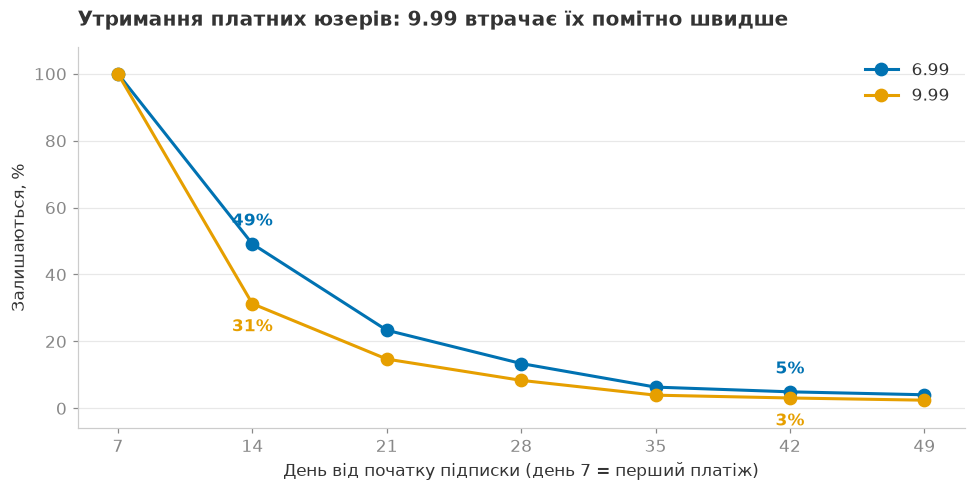

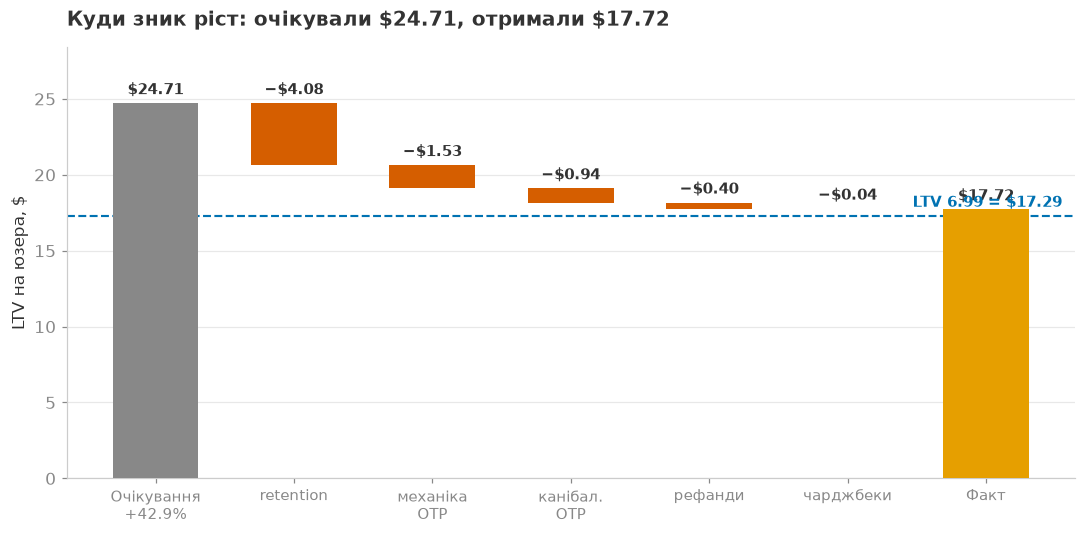

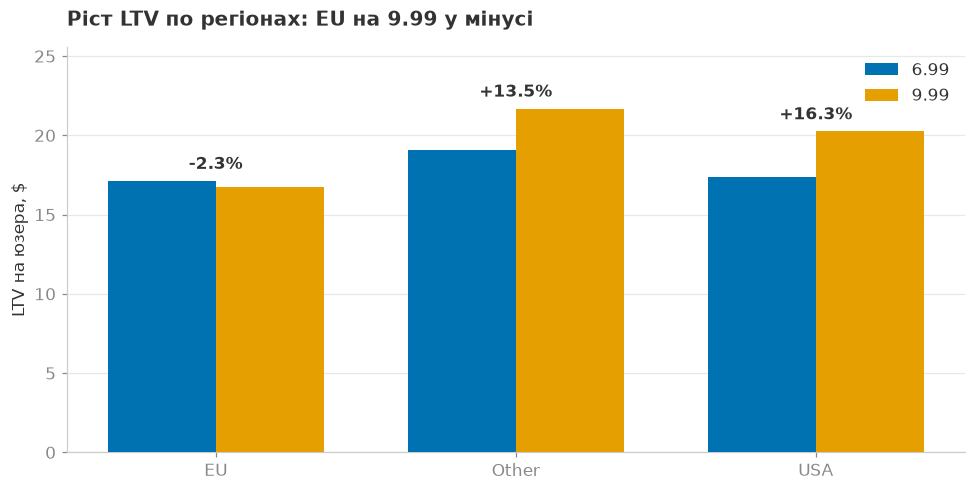

In [15]:
C699, C999, CLOSS, CINK, CMUT = '#0072B2', '#E69F00', '#D55E00', '#333333', '#888888'
plt.rcParams.update({'figure.dpi':110, 'font.size':11,
    'axes.spines.top':False, 'axes.spines.right':False, 'axes.edgecolor':'#cccccc',
    'text.color':CINK, 'axes.labelcolor':CINK, 'xtick.color':CMUT, 'ytick.color':CMUT,
    'grid.color':'#e8e8e8', 'grid.linewidth':0.8})

# ---------- 1. Криві утримання ----------
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(ret.index, ret['weekly 6.99'], marker='o', ms=8, lw=2, color=C699, label='6.99', zorder=3)
ax.plot(ret.index, ret['weekly 9.99'], marker='o', ms=8, lw=2, color=C999, label='9.99', zorder=3)
for d in [14, 42]:
    ax.annotate(f"{ret.loc[d,'weekly 6.99']:.0f}%", (d, ret.loc[d,'weekly 6.99']),
                textcoords='offset points', xytext=(0,12), ha='center', color=C699, fontweight='bold')
    ax.annotate(f"{ret.loc[d,'weekly 9.99']:.0f}%", (d, ret.loc[d,'weekly 9.99']),
                textcoords='offset points', xytext=(0,-18), ha='center', color=C999, fontweight='bold')
ax.set_title('Утримання платних юзерів: 9.99 втрачає їх помітно швидше', fontweight='bold', pad=14, loc='left')
ax.set_xlabel('День від початку підписки (день 7 = перший платіж)'); ax.set_ylabel('Залишаються, %')
ax.set_xticks(list(ret.index)); ax.set_ylim(-6, 108)
ax.grid(axis='y'); ax.set_axisbelow(True); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# ---------- 2. Водоспад: куди зник ріст ----------
short = {'механіка (OTP $15 не росте)':'механіка\nOTP', 'retention (менше списань)':'retention',
         'канібалізація OTP':'канібал.\nOTP', 'ріст рефандів':'рефанди', 'ріст чарджбеків':'чарджбеки'}
d_p = dec.rename(index=short)
b, t = ltv.loc['weekly 6.99'], ltv.loc['weekly 9.99']
naive = b['LTV'] * (9.99 / 6.99)

labels = ['Очікування\n+42.9%'] + list(d_p.index) + ['Факт']
run, bottoms, heights = naive, [0], [naive]
for v in -d_p.values:
    bottoms.append(run + v); heights.append(-v); run += v
bottoms.append(0); heights.append(t['LTV'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(labels)), heights, bottom=bottoms, width=0.62,
       color=[CMUT] + [CLOSS]*len(d_p) + [C999], zorder=3)
for i, (bt, h) in enumerate(zip(bottoms, heights)):
    txt = f"\\${naive:.2f}" if i == 0 else (f"\\${t['LTV']:.2f}" if i == len(labels)-1 else f"−\\${h:.2f}")
    ax.annotate(txt, (i, bt+h), textcoords='offset points', xytext=(0,6),
                ha='center', fontweight='bold', fontsize=10)
ax.axhline(b['LTV'], ls='--', lw=1.4, color=C699, zorder=2)
ax.annotate(f"LTV 6.99 = \\${b['LTV']:.2f}", (len(labels)-0.45, b['LTV']), textcoords='offset points',
            xytext=(0,6), ha='right', color=C699, fontsize=10, fontweight='bold')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9.5)
ax.set_title(f"Куди зник ріст: очікували \\${naive:.2f}, отримали \\${t['LTV']:.2f}",
             fontweight='bold', pad=14, loc='left')
ax.set_ylabel('LTV на юзера, \\$'); ax.set_ylim(0, naive*1.15)
ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ---------- 3. LTV по регіонах ----------
seg = full.pivot_table(index='region', columns='product', values='LTV', aggfunc='mean').round(2)
seg['ріст_%'] = (100*(seg['weekly 9.99']/seg['weekly 6.99'] - 1)).round(1)
seg = seg.sort_values('ріст_%')
fig, ax = plt.subplots(figsize=(9, 4.6)); x = np.arange(len(seg)); w = 0.36
ax.bar(x-w/2, seg['weekly 6.99'], w, color=C699, label='6.99', zorder=3)
ax.bar(x+w/2, seg['weekly 9.99'], w, color=C999, label='9.99', zorder=3)
for i, (_, r) in enumerate(seg.iterrows()):
    ax.annotate(f"{r['ріст_%']:+.1f}%", (i, max(r['weekly 6.99'], r['weekly 9.99'])),
                textcoords='offset points', xytext=(0,8), ha='center', fontweight='bold', color=CINK)
ax.set_xticks(x); ax.set_xticklabels(seg.index)
ax.set_title('Ріст LTV по регіонах: EU на 9.99 у мінусі', fontweight='bold', pad=14, loc='left')
ax.set_ylabel('LTV на юзера, \\$'); ax.set_ylim(0, seg[['weekly 6.99','weekly 9.99']].max().max()*1.18)
ax.grid(axis='y'); ax.set_axisbelow(True); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Висновок Блоку 2 (LTV на 49 днів):**
- LTV: **\$17.29 (6.99) → \$17.72 (9.99) = +2.5%** замість обіцяних +42.9% (Welch CI приросту +\$0.15…+\$0.71).
- Куди зникли +\$6.99/юзера проти наївного очікування: **retention −\$4.08** (головна причина), механіка OTP −\$1.53, канібалізація OTP −\$0.94, рефанди −\$0.40, чарджбеки −\$0.04.
- Сигнал мобайл-команди підтриманий: серед спостережених платників retention на 9.99 нижчий і є головним внеском у різницю LTV; через rollout-дизайн це не повний причинний доказ. Скарга сапорту підтверджена, але фінансово другорядна.
- **Сегменти: EU на 9.99 дає НИЖЧИЙ LTV (−\$0.40/юзера, CI [−0.71; −0.09])**; USA +16.3%, Other +13.5%. Тижневі когорти підтверджують стабільність розриву d14-retention у часі (повний LTV49 для пізніх когорт ще не дозрів — це межа даних, не аналізу).

product,weekly 6.99,weekly 9.99
тиждень_старту,,
2025-01-20,48.01,28.14
2025-01-27,48.31,28.13
2025-02-03,47.27,27.94
2025-02-10,46.52,29.54
2025-02-17,50.58,32.68
2025-02-24,51.29,35.98
2025-03-03,52.28,35.94


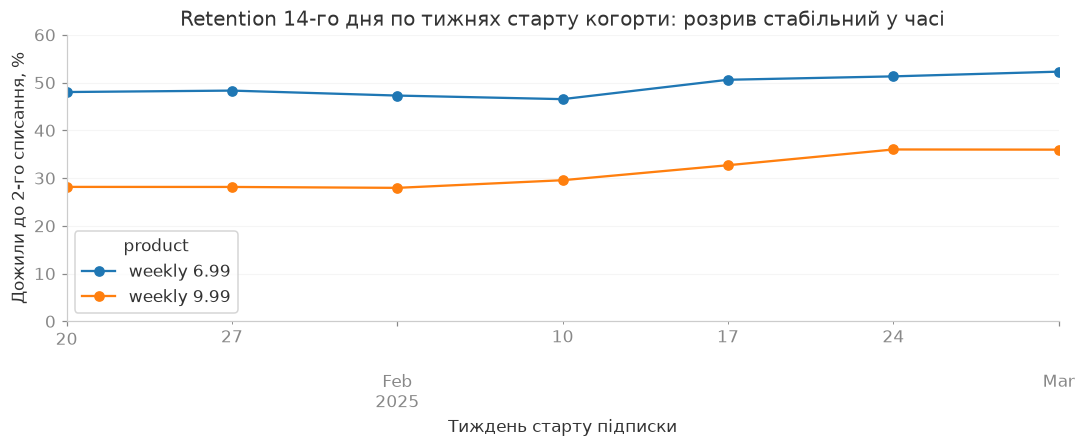

In [16]:
# --- Динаміка: retention 14-го дня по тижнях старту когорти ---
u14 = users[users['obs_days'] >= 14].copy()
u14['тиждень_старту'] = u14['date_started'].dt.to_period('W').dt.start_time
alive14 = set(o[o['diff_days'] == 14]['user_uuid'])
u14['d14'] = u14['user_uuid'].isin(alive14).astype(int)

din = (u14.pivot_table(index='тиждень_старту', columns='product', values='d14', aggfunc='mean') * 100).round(2)
display(din)
din.plot(figsize=(10, 4.2), marker='o')
plt.title('Retention 14-го дня по тижнях старту когорти: розрив стабільний у часі')
plt.ylabel('Дожили до 2-го списання, %'); plt.xlabel('Тиждень старту підписки')
plt.ylim(0, 60); plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# Блок 3: Revenue за 26.01–16.03 — скільки заробили/втратили на переході до 9.99

**Модельні рішення Блоку 3 — тут два РІЗНІ питання, розділяємо їх явно:**

**(А) Скільки грошей впало в касу за вікно 26.01–16.03 (календарний cash).**
Рахується по всіх списаннях з `order_date` у вікні, незалежно від дати старту юзера.
Ця звірка виведена в ячейці нижче першою.

**(Б) Скільки заробили/втратили ЧЕРЕЗ ПЕРЕХІД на 9.99 (порівняння цін).**
Порівнюємо зіставні когорти. **Базове визначення: старти 26.01–09.03** — обрано так, щоб
КОЖЕН юзер когорти фізично міг здійснити хоча б одне списання до 16.03 (перший платіж =
старт + 7 днів). Старти 10–16.03 (23 295 юзерів) до першого платежу дожити не могли —
включати їх у знаменник ARPU некоректно.
**Sensitivity (виведена таблицею):** (i) старти до 16.03 → +$93 тис.; (ii) базова → +$107 тис.;
(iii) зі стартерами 25.01 → +$109 тис. Висновок додатний при всіх розумних межах когорти;
конкретна сума — модельна оцінка, залежна від визначення популяції.

Інші рішення:
- Оплати лише в дати `order_date` (уточнення автора кейсу) → day-0 платежу не існує.
- OTP відносимо до дня старту юзера — підтверджено даними тесту: 100% OTP-покупок (1496/1496)
  відбулися в день покупки. Рефанди/чарджбеки дат не мають ніде в даних → відносимо до юзера
  когорти; вага ~3% виручки вікна, чутливість мала й симетрична.
- Контрфактуал «якби лишились на 6.99»: 9.99-когорта поводиться як 6.99-когорта.
- **Обмеження причинності (важливо):** в order_data лише ті, хто заплатив ≥1 раз; конверсію
  тріал→платіж по цінових групах ми не бачимо. Розмір когорт різний (112k vs 103k платників),
  і різниця розподілена по ВСІХ регіонах (EU −5.9k, USA −3.2k, Other −0.6k); Other у розкатці
  містить обидві ціни (52/48), тож недоставка Tier1 цього НЕ пояснює. Можливі пояснення — нижча
  тріал→платіж конверсія на 9.99 та/або нерівномірність спліта; це лише гіпотези. Нижчий retention
  після першого платежу сам по собі не доводить нижчу конверсію в перший платіж. Якщо вона справді нижча,
  повний ефект переходу на ВЕСЬ трафік гірший за оцінку на платниках.

In [17]:
# --- Блок 3: Revenue за календарне вікно 26.01–16.03 ---
W_START, W_END = pd.Timestamp('2025-01-26'), pd.Timestamp('2025-03-16')
COH_END = W_END - pd.Timedelta(days=7)   # 09.03: останній старт, що фізично міг заплатити у вікні

# (А) ЗВІРКА: повний календарний cash по підписці за вікно (усі order_date у вікні)
reb_all = o[(o['order_date'] >= W_START) & (o['order_date'] <= W_END)].copy()
reb_all['ціна'] = reb_all['Product Name'].map(price_map)
cal = reb_all.groupby('Product Name')['ціна'].agg(сума='sum', списань='count')
print('(А) Повний календарний cash по підписці за 26.01–16.03 (усі юзери):')
display(cal.round(0))
print(f"Разом: ${cal['сума'].sum():,.0f}.\n")

# (Б) Порівняння цін: базова когорта — старти 26.01–09.03 (кожен міг заплатити у вікні)
reb_cnt_w = reb_all.groupby('user_uuid').size().rename('списань_у_вікні')

def оцінка_когорти(s_from, s_to):
    coh = users[(users['date_started'] >= s_from) & (users['date_started'] <= s_to)]             [['user_uuid', 'product', 'price']].copy()
    coh = coh.merge(reb_cnt_w, on='user_uuid', how='left')
    coh['списань_у_вікні'] = coh['списань_у_вікні'].fillna(0).astype(int)
    coh['rev'] = coh['списань_у_вікні'] * coh['price']                + coh['user_uuid'].isin(otp_users).astype(int) * OTP_PRICE
    coh = coh.merge(df_refunds_data[['user_uuid', 'refund', 'chargeback']], on='user_uuid', how='left')              .fillna({'refund': 0, 'chargeback': 0})
    coh['rev'] -= coh['refund'] * coh['price'] + coh['chargeback'] * (coh['price'] + CB_FINE)
    g = coh.groupby('product').agg(юзерів=('user_uuid', 'size'), revenue=('rev', 'sum'))
    g['ARPU'] = g['revenue'] / g['юзерів']
    a6, a9 = g.loc['weekly 6.99', 'ARPU'], g.loc['weekly 9.99', 'ARPU']
    n9, rev9 = g.loc['weekly 9.99', 'юзерів'], g.loc['weekly 9.99', 'revenue']
    return g, a6, a9, n9, rev9, rev9 - n9 * a6, n9 * a6 * (9.99 / 6.99)

agg_b, a699, a999, n999, rev999, delta_b, naive_b = оцінка_когорти(W_START, COH_END)
hypo = n999 * a699
print('(Б) Базова когорта (старти 26.01–09.03):')
agg_disp = agg_b.copy(); agg_disp['ARPU'] = agg_disp['ARPU'].round(3)
display(agg_disp.round(0))
print(f"ARPU: 6.99 = {a699:.2f} | 9.99 = {a999:.2f} | ріст = {100*(a999/a699-1):.1f}%  (наївно +42.9%)")
print(f"Гіпотетичний світ (без підвищення): ${hypo:,.0f}")
print(f"Факт 9.99-когорти:                  ${rev999:,.0f}  →  оцінка ефекту = {delta_b:+,.0f}")
print(f"Наївне очікування (+42.9%):         ${naive_b:,.0f}  →  недобір = {naive_b - rev999:,.0f}")

# Sensitivity: як сума залежить від меж когорти
print('\nSensitivity до меж когорти:')
sens_rows = []
for name, s_from, s_to in [('(i) старти 26.01–16.03 (широка)', W_START, W_END),
                            ('(ii) старти 26.01–09.03 (базова)', W_START, COH_END),
                            ('(iii) старти 25.01–09.03', pd.Timestamp('2025-01-25'), COH_END)]:
    _, s6, s9, sn9, srev9, sd, snaive = оцінка_когорти(s_from, s_to)
    sens_rows.append({'когорта': name, 'ARPU_ріст_%': round(100*(s9/s6-1), 1),
                      'ефект_$': round(sd), 'недобір_$': round(snaive - srev9)})
display(pd.DataFrame(sens_rows))
print('Ефект переходу додатний при всіх розумних межах когорти: ≈ +$93…109 тис.;')
print('недобір до обіцянки ≈ −$461…491 тис. Конкретна сума — модельна оцінка на платниках.')

(А) Повний календарний cash по підписці за 26.01–16.03 (усі юзери):


,сума,списань
Product Name,,
weekly 6.99,1180681.0,168910
weekly 9.99,1301407.0,130271


Разом: $2,482,088.



(Б) Базова когорта (старти 26.01–09.03):


,юзерів,revenue,ARPU
product,,,
weekly 6.99,97239,1452656.0,15.0
weekly 9.99,88608,1430688.0,16.0


ARPU: 6.99 = 14.94 | 9.99 = 16.15 | ріст = 8.1%  (наївно +42.9%)
Гіпотетичний світ (без підвищення): $1,323,717
Факт 9.99-когорти:                  $1,430,688  →  оцінка ефекту = +106,970
Наївне очікування (+42.9%):         $1,891,837  →  недобір = 461,149

Sensitivity до меж когорти:


,когорта,ARPU_ріст_%,ефект_$,недобір_$
0,(i) старти 26.01–16.03 (широка),6.8,93170,491117
1,(ii) старти 26.01–09.03 (базова),8.1,106970,461149
2,(iii) старти 25.01–09.03,7.9,108949,479850


Ефект переходу додатний при всіх розумних межах когорти: ≈ +$93…109 тис.;
недобір до обіцянки ≈ −$461…491 тис. Конкретна сума — модельна оцінка на платниках.


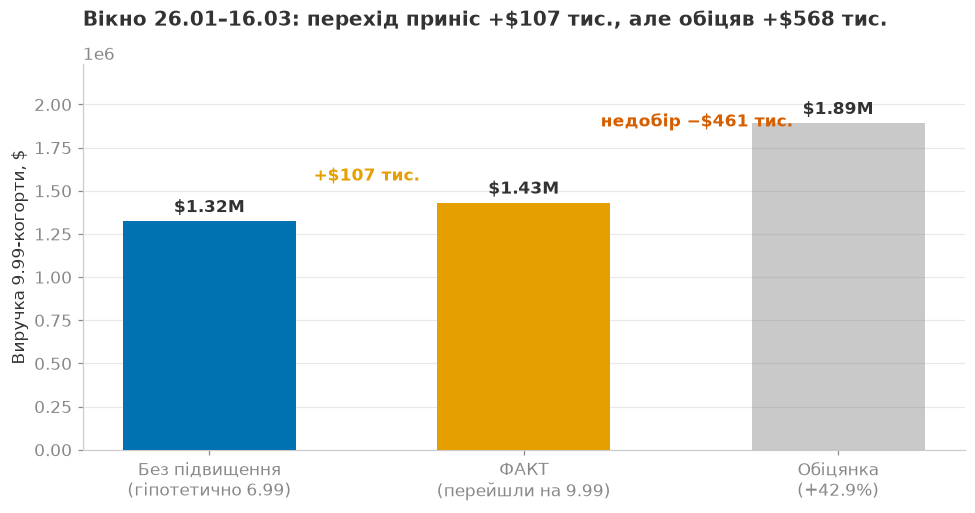

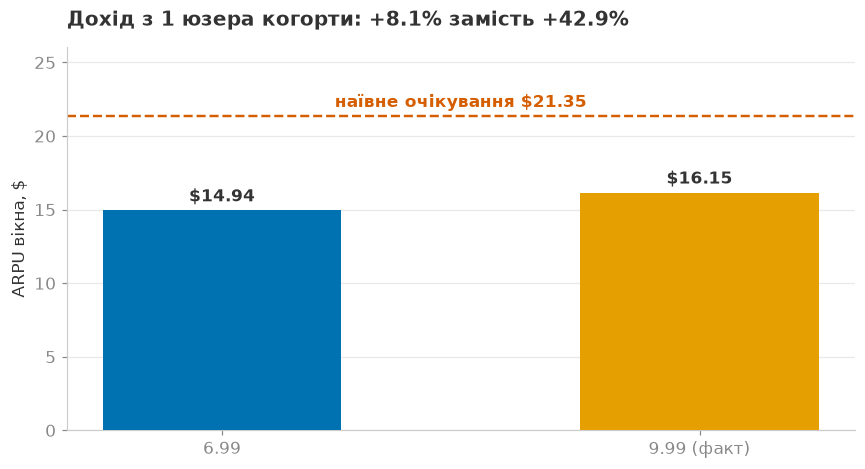

In [18]:
# --- Графіки Блоку 3 ---

# Графік 1: три світи для 9.99-когорти (тотали вікна 26.01–16.03)
fig, ax = plt.subplots(figsize=(9, 4.8))
worlds = ['Без підвищення\n(гіпотетично 6.99)', 'ФАКТ\n(перейшли на 9.99)', 'Обіцянка\n(+42.9%)']
vals = [hypo, rev999, naive_b]
bars = ax.bar(worlds, vals, width=0.55, color=[C699, C999, CMUT], zorder=3)
bars[2].set_alpha(0.45)
for x_, v in zip([0, 1, 2], vals):
    ax.annotate(f"\\${v/1e6:.2f}M", (x_, v), textcoords='offset points', xytext=(0, 6),
                ha='center', fontweight='bold')
ax.annotate(f"+\\${(rev999-hypo)/1e3:,.0f} тис.", (0.5, rev999*1.09), ha='center',
            color=C999, fontweight='bold')
ax.annotate(f"недобір −\\${(naive_b-rev999)/1e3:,.0f} тис.", (1.55, naive_b*0.99), ha='center',
            color=CLOSS, fontweight='bold')
ax.set_title(f"Вікно 26.01–16.03: перехід приніс +\\${(rev999-hypo)/1e3:,.0f} тис., "
             f"але обіцяв +\\${(naive_b-hypo)/1e3:,.0f} тис.", fontweight='bold', pad=14, loc='left')
ax.set_ylabel('Виручка 9.99-когорти, \\$'); ax.set_ylim(0, naive_b*1.18)
ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# Графік 2: дохід з 1 юзера (ARPU вікна) проти наївного очікування
naive_arpu = a699 * (9.99 / 6.99)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(['6.99', '9.99 (факт)'], [a699, a999], width=0.5, color=[C699, C999], zorder=3)
ax.axhline(naive_arpu, ls='--', lw=1.6, color=CLOSS)
ax.annotate(f"наївне очікування \\${naive_arpu:.2f}", (0.5, naive_arpu), textcoords='offset points',
            xytext=(0, 6), ha='center', color=CLOSS, fontweight='bold')
for x_, v in zip([0, 1], [a699, a999]):
    ax.annotate(f"\\${v:.2f}", (x_, v), textcoords='offset points', xytext=(0, 6),
                ha='center', fontweight='bold')
ax.set_title(f"Дохід з 1 юзера когорти: +{100*(a999/a699-1):.1f}% замість +42.9%",
             fontweight='bold', pad=14, loc='left')
ax.set_ylabel('ARPU вікна, \\$'); ax.set_ylim(0, naive_arpu*1.22)
ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Висновок Блоку 3 (Revenue 26.01–16.03):**
- Дохід з 1 юзера когорти (ARPU вікна, базова когорта стартів 26.01–09.03): \$14.94 → \$16.15 = **+8.1%**
  замість обіцяних +42.9%.
- **Модельна оцінка ефекту переходу: ≈ +\$107 тис.** проти світу «лишились на 6.99»
  (sensitivity до меж когорти: +\$93…109 тис.) — модельна оцінка додатна для спостережених платників…
- …але **недобір до обіцянки ≈ −\$461 тис.** за 7 тижнів (до −\$491 тис. при ширшій когорті):
  отримано лише ~19% обіцяного приросту.
- Це оцінка на платниках order_data: конверсію тріал→платіж по цінах дані не показують;
  якщо на 9.99 вона нижча — повний ефект на весь трафік гірший.
- Відповідь CEO: revenue виріс, але в рази слабше за очікування «+42.9%». Причини — retention,
  апсел і рефанди (Блок 2) плюс структура виручки (OTP не росте з ціною).

In [19]:
df_marketing_spend_data['date'] = pd.to_datetime(df_marketing_spend_data['date'])

# 1) какой период покрывают расходы?
display(df_marketing_spend_data['date'].agg(['min', 'max']))

# 2) структура: каналы × регионы × группы
display(df_marketing_spend_data.groupby(['channel', 'country_group', 'group']).size())

# 3) деньги: спенд по регион × группа + CPC по группам
display(df_marketing_spend_data.groupby(['country_group', 'group'])['spend'].sum())
display(df_marketing_spend_data.groupby('group').apply(lambda g: g['spend'].sum() / g['clicks'].sum()))

min   2025-01-05
max   2025-02-23
Name: date, dtype: datetime64[us]

channel   country_group  group  
Facebook  EU             control    36
                         test       40
          Tier1          control    27
                         test       23
          USA            control    40
                         test       44
Google    EU             control    30
                         test       38
          Tier1          control    21
                         test       21
          USA            control    21
                         test       20
Organic   EU             control    19
                         test       19
          Tier1          control    17
                         test       17
          USA            control    16
                         test       18
TikTok    EU             control    29
                         test       28
          Tier1          control    19
                         test       22
          USA            control    24
                         test       20
dtype: int64

country_group  group  
EU             control    21209.19
               test       21354.59
Tier1          control     4469.18
               test        4096.78
USA            control    16339.79
               test       16397.24
Name: spend, dtype: float64

group
control    0.690033
test       0.737381
dtype: float64

# Блок 4: ROAS по сегментах — чи окупається залучення при новій ціні

**Ключовий факт даних:** `marketing_spend_data` — це рекламний рахунок за трафік **самого A/B-тесту**: кліки збігаються з `test_data` день у день 1:1 (117 646 = 117 646, максимальна розбіжність по будь-якому дню = 0). Спенду розкатки в даних немає.

**Модельні рішення:**
- Вікно те саме, що в Завданні 1: **11–24.01** (хвости спенду = ті самі хвости тесту).
- **CAC** (вартість залучення 1 покупця) = спенд вікна / покупці вікна (з `test_data`), по регіон × група.
- **Цінність покупця** = LTV49 з Блоку 2, по регіону × **фактично доставленій ціні**: Tier1-test ціну 9.99 не отримав → обом армам Tier1 ставимо LTV(Other, 6.99); маппінг регіонів Tier1 ↔ Other.
- **ROAS49 = LTV49 / CAC** — скільки доларів цінності повертає 1 долар реклами за 49 днів.
- **ROAS по регіонах — оптимістичний proxy:** CAC порахований на оформлення тріалу
  (purchase у тесті), а LTV — на платниках order_data; конверсія тріал→платіж невідома, тому за прийнятого
  регіонального LTV фактичний ROAS не вищий за показаний. Порівняння армів чесне лише за умови однакової
  тріал→платіж конверсії; її різницю дані не ідентифікують.
- **ROAS по каналах:** спенд і покупці по каналах у даних є (test_data має channel) → CAC канальний
  рахується напряму; канального LTV немає → цінність = міст із region × доставлена ціна. Через цей міст
  канальні значення не є строгою верхньою межею: справжній LTV каналу може бути як нижчим, так і вищим.
- Припущення (озвучити на захисті): LTV пораховано на популяції розкатки, застосовуємо до покупців тесту тих самих регіон × ціна — іншого моста в даних немає.

In [20]:
# --- Блок 4: CAC та ROAS по регіон × група (вікно 11–24.01) ---

# 1. Спенд у вікні тесту
m_win = df_marketing_spend_data[(df_marketing_spend_data['date'] >= period_start) &
                                (df_marketing_spend_data['date'] <= period_end)]
spend = m_win.groupby(['country_group', 'group'])['spend'].sum().unstack()

# 2. Покупці у вікні (з test_data)
buyers = (df_period[df_period['event_name'] == 'purchase']
          .groupby(['country_group', 'group'])['user_id'].nunique().unstack())

# 3. CAC = спенд / покупці
cac = (spend / buyers).round(2)

# 4. Цінність покупця = LTV49 по регіону × ДОСТАВЛЕНІЙ ціні (Tier1 → Other, обидва арми 6.99)
ltv_reg = full.pivot_table(index='region', columns='product', values='LTV', aggfunc='mean').round(2)
value = pd.DataFrame(index=['EU', 'USA', 'Tier1'], columns=['control', 'test'], dtype=float)
value.loc['EU']    = [ltv_reg.loc['EU', 'weekly 6.99'],    ltv_reg.loc['EU', 'weekly 9.99']]
value.loc['USA']   = [ltv_reg.loc['USA', 'weekly 6.99'],   ltv_reg.loc['USA', 'weekly 9.99']]
value.loc['Tier1'] = [ltv_reg.loc['Other', 'weekly 6.99'], ltv_reg.loc['Other', 'weekly 6.99']]

# 5. ROAS = цінність / вартість залучення
roas = (value / cac).round(3)

summary = pd.concat({'спенд_$': spend.round(0), 'покупці': buyers, 'CAC_$': cac,
                     'LTV49_$': value, 'ROAS49': roas}, axis=1)
display(summary)

delta_roas = (100 * (roas['test'] / roas['control'] - 1)).round(1)
print('ΔROAS test vs control, %:')
display(delta_roas)

# 6. CPC по каналах: де саме подорожчало залучення
cpc_ch = m_win.groupby(['channel', 'group']).apply(
    lambda g: g['spend'].sum() / g['clicks'].sum(), include_groups=False).round(4).unstack()
cpc_ch['Δ_%'] = (100 * (cpc_ch['test'] / cpc_ch['control'] - 1)).round(1)
print('CPC по каналах:')
display(cpc_ch)

спенд_$          покупці         CAC_$        LTV49_$         ROAS49  \
group  control     test control  test control   test control   test control   
EU     18237.0  19901.0    1480  1429   12.32  13.93   17.11  16.71   1.389   
Tier1   3886.0   3810.0     360   367   10.79  10.38   19.09  19.09   1.769   
USA    14014.0  15335.0    1585  1476    8.84  10.39   17.40  20.24   1.968   

              
group   test  
EU     1.200  
Tier1  1.839  
USA    1.948

ΔROAS test vs control, %:


EU      -13.6
Tier1     4.0
USA      -1.0
dtype: float64

CPC по каналах:


group,control,test,Δ_%
channel,,,
Facebook,0.6449,0.7410,14.9
Google,1.0030,0.9967,-0.6
Organic,0.1009,0.0999,-1.0
TikTok,0.5516,0.5494,-0.4


In [21]:
# --- ROAS по каналах: канал × регіон × цінова група ---
# Канального LTV у даних НЕ існує (order_data/user_data без channel) → цінність покупця
# переносимо мостом із region × доставлена ціна (те саме припущення, що й вище).
spend_ch = m_win.groupby(['channel', 'country_group', 'group'])['spend'].sum()
buyers_ch = (df_period[df_period['event_name'] == 'purchase']
             .groupby(['channel', 'country_group', 'group'])['user_id'].nunique())

rows_ch = []
for (ch, reg, grp), sp in spend_ch.items():
    b_ = buyers_ch.get((ch, reg, grp), 0)
    if b_ == 0:
        continue
    ltv_b = value.loc[reg, grp]          # міст: LTV49(region × доставлена ціна); Tier1 → Other 6.99
    rows_ch.append({'канал': ch, 'регіон': reg, 'група': grp,
                    'спенд_$': round(sp), 'покупці': b_,
                    'CAC_$': round(sp / b_, 2), 'LTV49_$': round(ltv_b, 2),
                    'ROAS49': round(ltv_b / (sp / b_), 2)})
roas_ch = pd.DataFrame(rows_ch)
piv_ch = roas_ch.pivot_table(index='канал', columns=['регіон', 'група'], values='ROAS49')
print('ROAS49 по каналах (міст LTV із region × ціна):')
display(piv_ch.round(2))

print('Клітинки з ROAS49 < 1:')
display(roas_ch[roas_ch['ROAS49'] < 1])

print('Застереження: (1) Tier1-канали — малі вибірки покупців (16–221), читати як шум;')
print('(2) Organic має символічний спенд → величезний ROAS, очікувано;')
print('(3) LTV по каналу — припущення-міст: канальні відмінності LTV даними не покриті.')

ROAS49 по каналах (міст LTV із region × ціна):


регіон        EU          Tier1            USA       
група    control   test control   test control   test
канал                                                
Facebook    1.60   1.23    1.72   1.71    2.01   1.94
Google      0.88   0.89    1.37   1.20    1.19   1.46
Organic    11.20  10.01   12.35  13.18   12.87  12.09
TikTok      1.83   1.54    2.30   3.06    2.37   2.31

Клітинки з ROAS49 < 1:


,канал,регіон,група,спенд_$,покупці,CAC_$,LTV49_$,ROAS49
6,Google,EU,control,8509,439,19.38,17.11,0.88
7,Google,EU,test,8428,450,18.73,16.71,0.89


Застереження: (1) Tier1-канали — малі вибірки покупців (16–221), читати як шум;
(2) Organic має символічний спенд → величезний ROAS, очікувано;
(3) LTV по каналу — припущення-міст: канальні відмінності LTV даними не покриті.


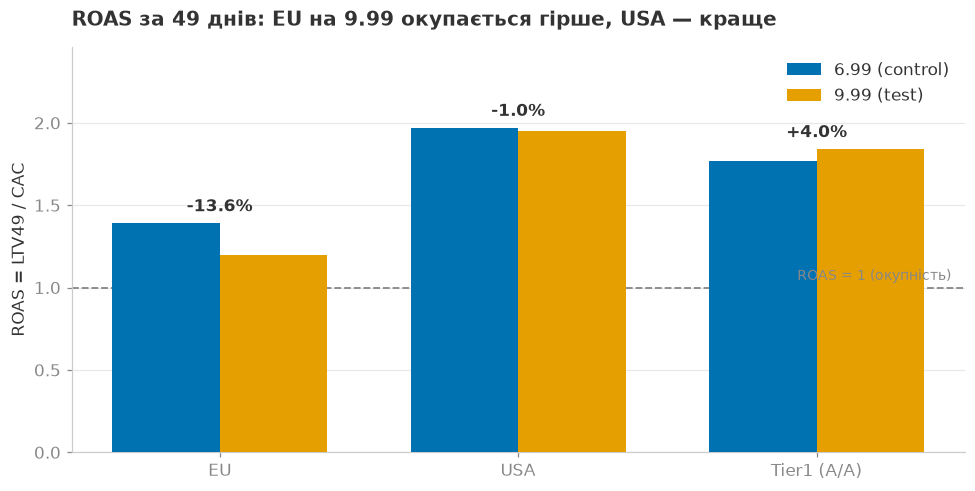

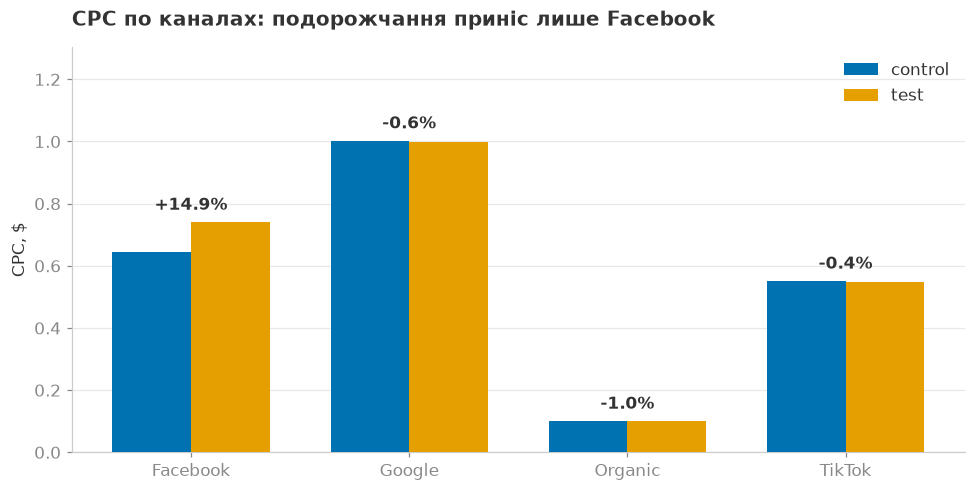

In [22]:
# --- Графіки Блоку 4 ---

# Графік 1: ROAS по регіонах
regs = ['EU', 'USA', 'Tier1']
fig, ax = plt.subplots(figsize=(9, 4.6)); x = np.arange(3); w = 0.36
ax.bar(x - w/2, roas.loc[regs, 'control'], w, color=C699, label='6.99 (control)', zorder=3)
ax.bar(x + w/2, roas.loc[regs, 'test'],    w, color=C999, label='9.99 (test)', zorder=3)
for i, r in enumerate(regs):
    ax.annotate(f"{delta_roas[r]:+.1f}%", (i, max(roas.loc[r])), textcoords='offset points',
                xytext=(0, 8), ha='center', fontweight='bold')
ax.axhline(1.0, ls='--', lw=1.2, color=CMUT)
ax.annotate('ROAS = 1 (окупність)', (2.45, 1.0), textcoords='offset points', xytext=(0, 5),
            ha='right', fontsize=9, color=CMUT)
ax.set_xticks(x); ax.set_xticklabels(['EU', 'USA', 'Tier1 (A/A)'])
ax.set_title('ROAS за 49 днів: EU на 9.99 окупається гірше, USA — краще', fontweight='bold', pad=14, loc='left')
ax.set_ylabel('ROAS = LTV49 / CAC'); ax.set_ylim(0, roas.values.max() * 1.25)
ax.grid(axis='y'); ax.set_axisbelow(True); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# Графік 2: CPC по каналах
chs = list(cpc_ch.index)
fig, ax = plt.subplots(figsize=(9, 4.6)); x = np.arange(len(chs)); w = 0.36
ax.bar(x - w/2, cpc_ch['control'], w, color=C699, label='control', zorder=3)
ax.bar(x + w/2, cpc_ch['test'],    w, color=C999, label='test', zorder=3)
for i, c in enumerate(chs):
    ax.annotate(f"{cpc_ch.loc[c, 'Δ_%']:+.1f}%", (i, max(cpc_ch.loc[c, ['control', 'test']])),
                textcoords='offset points', xytext=(0, 8), ha='center', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_title('CPC по каналах: подорожчання приніс лише Facebook', fontweight='bold', pad=14, loc='left')
ax.set_ylabel('CPC, \\$'); ax.set_ylim(0, cpc_ch[['control', 'test']].values.max() * 1.3)
ax.grid(axis='y'); ax.set_axisbelow(True); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Читання результатів і висновок Блоку 4:**

- **CAC зріс там, де доставлено 9.99:** EU $12.32 → $13.93 (+13.0%), USA $8.84 → $10.39 (+17.5%). Tier1 (A/A) — різниця в межах шуму (−3.8%).
- **CPC: у test-армі дорожчим був лише Facebook-трафік (+14.9%)**; Google / TikTok / Organic — без змін (±1%), у Tier1-A/A різниці немає. Це кореляція; механізм (закупівля, мікс трафіку, реакція аукціону) цими даними не ідентифікується.
- **ROAS49 по регіонах:** EU 1.39 → 1.20 (**−13.6%**) — у 9.99-когорти нижчий LTV-proxy, а залучення дорожче → окупність погіршується з обох боків дробу. USA 1.97 → 1.95 (**−1.0%**) — вищий LTV 9.99-когорти (+16.3%) приблизно компенсував подорожчання CAC: окупність не покращилась, але й не погіршилась.
- **Канальний розріз спростовує «все окупається»: Google-EU proxy < 1 на ОБОХ цінах (0.88 / 0.89)** при ~440–450 покупцях на арм. Це сильний сигнал для окремого аудиту закупівлі, але не доказ збитковості: канального LTV у даних немає, а міст із регіонального LTV може зміщувати оцінку в обидва боки. Решта каналів у EU/USA — вище 1 у цій proxy-оцінці.
- **Tier1 (A/A): +4.0% ROAS при однаковому LTV** — шум малої вибірки покупців (360 vs 367); задає масштаб похибки ROAS на цих обсягах.

**Висновок для рекомендації:** у **EU** ціна 9.99 поєднується з погіршенням і цінності юзера, і вартості залучення (ROAS −13.6%) → відкат/перетест. У **USA** rollout дає позитивний сигнал: LTV 9.99-когорти +16.3%, оцінка грошей Блоку 3 додатна, ROAS нейтральний; 9.99 можна лишити, але рішення варто підтвердити тестом повної економіки. **Tier1: валідного рандомізованого тесту ціни не було** (в A/B ціну не доставили); rollout-дані регіону Other містять обидві ціни (52/48) і дають **непрямий позитивний сигнал** (+13.5% LTV) — але це спостережні дані, не тест → потрібен коректний тест. Окремо: Google-EU — кандидат на аудит закупівлі.

# Блок 5: Підсумок кейсу та рекомендація

## Що показав аналіз

1. **Початковий A/B-тест не давав підстав чекати +42.9% до всіх грошей.** Валідне вікно — 11–24.01; 09–10.01 мали збої збору даних, а Tier1 фактично був A/A, бо ціну 9.99 там не доставили.
2. **Конверсія в основну покупку майже не змінилася, але це не вся воронка.** У EU доплата $15 впала приблизно на третину; саме цю метрику компанія не перевірила.
3. **Дохід з платника за 49 днів виріс лише на 2.5%:** $17.29 → $17.72 замість +42.9%. Головна причина — клієнти на 9.99 рідше робили повторні платежі; у EU дохід з платника навіть знизився на 2.3%.
4. **За моделлю перехід додав близько $107 тис.**, але це лише близько 19% очікуваного приросту. Оцінка побудована на платниках; вплив ціни на перехід від безкоштовного тріалу до першої оплати даними не покритий.
5. **Окупність реклами залежить від регіону.** У EU вона погіршилася на 13.6%; Google EU повертає близько $0.88–0.89 на кожен витрачений $1 у попередній оцінці та потребує окремого аудиту.

## Рекомендація

- **EU:** відкотити 9.99 або перетестувати проміжну ціну. Тут одночасно гірші повторні платежі, доплата $15, дохід з платника та окупність реклами.
- **USA:** залишити 9.99 як робочий варіант, але підтвердити рішення новим тестом повної економіки.
- **Tier1:** провести коректний рандомізований тест, у якому 9.99 справді доставляється тестовій групі.
- **Наступні цінові тести:** оцінювати разом основну покупку, доплату $15, повторні платежі, повернення коштів і окупність реклами — не лише одну конверсію.

**Фінальний висновок:** єдина ціна для всіх ринків не працює однаково. Рішення потрібно приймати окремо для EU, USA і Tier1 та за повною економікою клієнта.